Copyright 2019 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

### Imports and Utils

In [1]:
import jax.numpy as jnp
import jax
from jax import random
from jax.example_libraries import optimizers
from jax import jit, grad, vmap
from jax.nn import one_hot

import functools
from sklearn.model_selection import train_test_split

import neural_tangents as nt
from neural_tangents import stax

from examples.classificationDataGeneration import make_classification_dataset, demo_2d_examples, plot_2d_kde, plot_train_test_split

from functools import partial
import seaborn as sns

%load_ext autoreload
%autoreload 2

2025-10-22 17:24:28.247721: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-22 17:24:28.247763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-22 17:24:28.248849: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-22 17:24:28.832126: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
print(jax.devices())

[cuda(id=0)]


In [3]:
sns.set(font_scale=1.3)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

import matplotlib.pyplot as plt

def format_plot(x=None, y=None):
    # plt.grid(False)
    ax = plt.gca()
    if x is not None:
        plt.xlabel(x, fontsize=20)
    if y is not None:
        plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
    plt.gcf().set_size_inches(
        shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
        shape[1] * 1.5 * plt.gcf().get_size_inches()[1])
    plt.tight_layout()

legend = functools.partial(plt.legend, fontsize=10)

# Neural Tangents Classification

In this notebook we explore the training of infinitely-wide, Bayesian, neural networks using a library called [Neural Tangents](https://github.com/google/neural-tangents). Recent work has shown that such networks are Gaussian Processes with a particular compositional kernel called the NNGP kernel. More recently, it was shown that predictions resulting from these networks following Gradient Descent are Gaussian with a distribution that can be computed in closed form using the [Neural Tangent Kernel](). Neural Tangents provides a high level library to compute NNGP and NT kernels for a wide range of neural networks. See [the paper]() for a more detailed description of the library itself.

Our goal will be to train neural networks on a synthetic classification task. We'll then compare the results of these fit networks with the prediction of the NTK theory.

## Warm Up: Creating a Dataset

We are interested in classification tasks, because ultimately we want to develop a framework for studying catastrophic forgetting in neural networks using Neural Tangents. Our dataset will consist of K approximately evenly spaced N-dimensional Gaussian centers inside an N-D hypercube of edge length M. We will take these gaussians to be isotropic with a user-specified overlap.

The benefit of this set up is that a combinatorial number of unique classification tasks can be generated by varying the assignment of each gaussian to one of C classes. This allows us to generate a wide variety of tasks with varying degrees of complexity.

In [4]:
key = random.PRNGKey(10)

Demo: K=9, overlap=0.1 -> sigma=0.07767


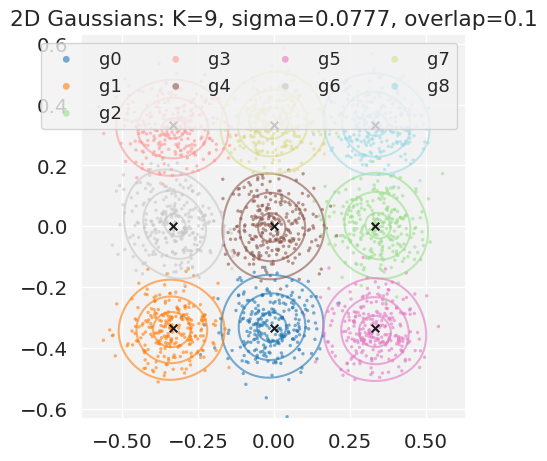

Classification Task: C=2


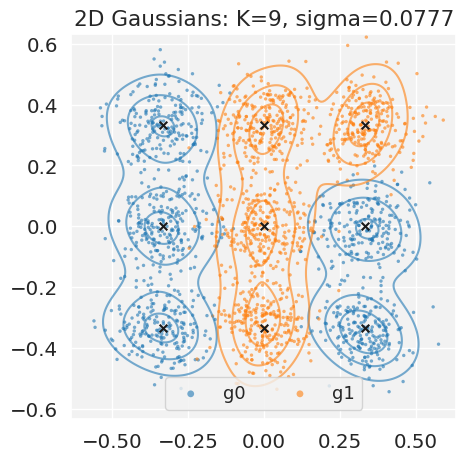

In [5]:
#visualize demos (this will show 4 plots for Ks=(9,16) and overlaps=(0.2, 0.6))
demo_2d_examples(M=1.0, Ks=(9,), overlaps=(0.1,), samples_per_gaussian=250, random_state=42)

# create a classification dataset
C=2  # number of classes
N=2 # number of dimensions
ds = make_classification_dataset(N=N, K=9, M=1.0, C=C, P=2000, overlap=0.1, random_state=1)
X, y = ds['X'], ds['y']
assignment = ds['assignment']  # dict gaussian_idx -> class
centers = ds['centers']
sigma = ds['sigma']
print(f"Classification Task: C={C}")
_ = plot_2d_kde(centers, sigma, X, y)

Let's now generate our train and test splits and visualize the train and test data in 2D.

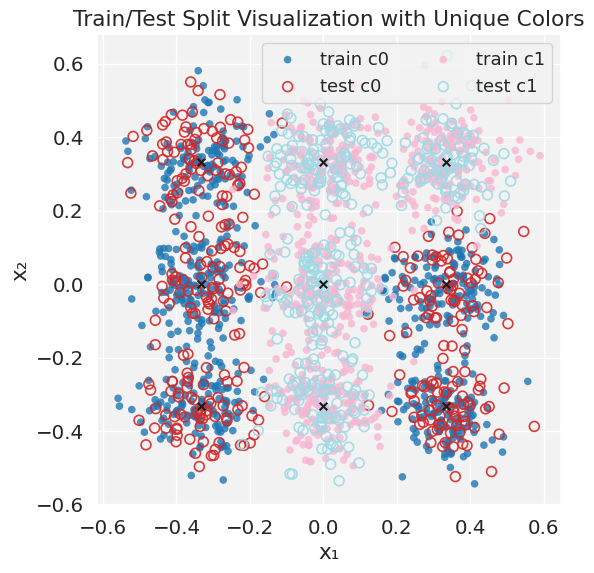

In [6]:
#let's train test split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
plot_train_test_split(X_train, y_train, X_test, y_test, centers, title="Train/Test Split Visualization with Unique Colors")

In [7]:
#transform to jax arrays
train_xs, test_xs, train_ys, test_ys = jnp.array(X_train), jnp.array(X_test), jnp.array(y_train), jnp.array(y_test)
train_ys_oh = one_hot(train_ys, C).astype(jnp.float32)   # (n_train, C)
test_ys_oh  = one_hot(test_ys,  C).astype(jnp.float32)   # (n_test, C)
train = (train_xs, train_ys_oh)
test = (test_xs, test_ys_oh)

## Defining a Neural Network

The first thing we need to do is define a neural network. We'll start out with a simple fully-connected network using `Erf` nonlinearities. We describe our network using our neural network library that shares syntax and code with JAX's own library called [stax](https://github.com/google/jax#neural-net-building-with-stax). Layers in `jax.example_libraries.stax` are pairs of functions `(init_fn, apply_fn)` where `init_fn(key, input_shape)` draws parameters randomly and `apply_fn(params, xs)` computes outputs of the function for specific inputs. These layers can be composed using `serial` and `parallel` combinators to produce new `(init_fn, apply_fn)` pairs.

Similarly, layers in `neural_tangents.stax` are triplets of functions `(init_fn, apply_fn, kernel_fn)` where the first two functions are the same as their `stax` equivalent but the third function, `kernel_fn`, computes infinite-width GP kernels corresponding to the layer. Again these layers can be composed using `serial` and `parallel` to build kernels for complicated architectures. Fully-connected layers in `neural_tangents.stax` are created using the `Dense` layer which is defined by,
$$z^{l+1}_i = \frac{\sigma_w}{\sqrt{N_{in}}} \sum_j W_{ij} z^{l}_i + \sigma_b b_i$$
where $W_{ij}, b_i\sim\mathcal N(0,1)$ at initialization and $\sigma_w, \sigma_b$ sets the scales of the weights and biases respectively.

In the case of classification we take the linear output to be C-dimensional where C is the number of classes. We then take the predicted class to be the index of the largest output value.

In [8]:
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(32, W_std=1.5, b_std=0.05), stax.Erf(),
    # stax.Dense(32, W_std=1.5, b_std=0.05), stax.Erf(),
    stax.Dense(C, W_std=1.5, b_std=0.05)
)

apply_fn = jit(apply_fn)
kernel_fn = jit(kernel_fn, static_argnames='get')

Here the lines `apply_fn = jit(apply_fn)` and `kernel_fn = jit(kernel_fn, static_argnames='get')` use a [JAX feature](https://github.com/google/jax#compilation-with-jit) that compiles functions so that they are executed as single calls to the GPU.

Next, let's take several random draws of the parameters of the network and plot what the functions look like.

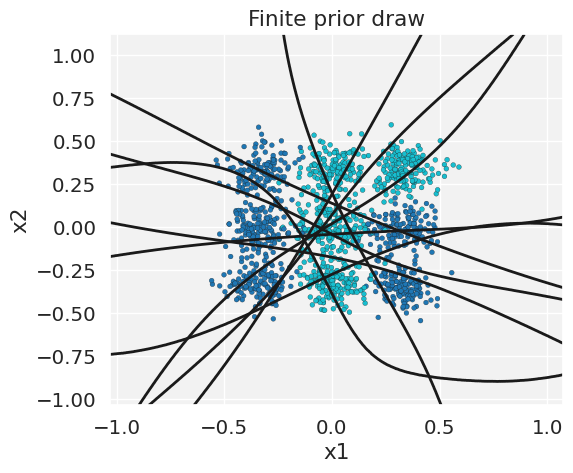

In [9]:
def make_grid_2d(X, n=300, pad=0.5):
    xmin, xmax = float(X[:,0].min())-pad, float(X[:,0].max())+pad
    ymin, ymax = float(X[:,1].min())-pad, float(X[:,1].max())+pad
    xs = jnp.linspace(xmin, xmax, n)
    ys = jnp.linspace(ymin, ymax, n)
    Xg = jnp.stack(jnp.meshgrid(xs, ys, indexing='xy'), axis=-1).reshape(-1, 2)
    return xs, ys, Xg

def getLogits_NTK(logit_fn, X, n=300, pad=0.5):
    xs, ys, Xg = make_grid_2d(X, n=n, pad=pad)
    logits = logit_fn(Xg)                            # (G, C)
    Z = jnp.argmax(logits, axis=1).reshape(ys.size, xs.size)  # class map
    return xs, ys, logits, Z

def plot_decision_boundary_2d(xs_, ys_, logits_, Zs_, C, n=300, pad=0.5, title=''):
    # margin between top-1 and top-2 logits for boundary line
    if not isinstance(logits_, list):
        logits_ = [logits_]
    if not isinstance(xs_, list):
        xs_ = [xs_]
    if not isinstance(ys_, list):
        ys_ = [ys_]
    if not isinstance(Zs_, list):
        Zs_ = [Zs_]
    assert len(xs_) == len(ys_) == len(logits_) == len(Zs_)
    plt.figure(figsize=(6,5))
    for i, (xs, ys, logits, Z) in enumerate(zip(xs_, ys_, logits_, Zs_)):
        top2 = jnp.sort(logits, axis=1)[:, -2:]         # (G, 2)
        margin = (top2[:, 1] - top2[:, 0]).reshape(ys.size, xs.size)
        if C == 2:
            # Signed margin => robust zero crossing
            margin = (logits[:, 0] - logits[:, 1]).reshape(ys.size, xs.size)
            plt.contour(xs, ys, margin, levels=[0.0], colors='k', linewidths=2.0)
        else:
            Z = jnp.argmax(logits, axis=1).reshape(ys.size, xs.size)
            plt.contourf(xs, ys, Z, levels=jnp.arange(-0.5, C, 1.0), alpha=0.6, cmap='tab10')
            # Optional: overlay region boundaries between integer labels
            plt.contour(xs, ys, Z, levels=jnp.arange(C - 1) + 0.5, colors='k', linewidths=1.0)

    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=12, cmap='tab10', edgecolors='k', linewidths=0.2)
    plt.title(title or 'Decision regions (argmax) + boundary (top1-top2==0)')
    plt.xlabel('x1'); plt.ylabel('x2'); plt.tight_layout()
    plt.show()

#each p in prior_draws is (num_test_points, C)
#to get the predicted labels take the argmax across axis 1
xs, ys, logits, Zs = [], [], [], []
prior_draws = []
for _ in range(10):
    key, net_key = random.split(key)
    _, params = init_fn(net_key, (-1, N))
    out = getLogits_NTK(lambda x: apply_fn(params, x), test_xs, n=600, pad=0.5)
    xs += [out[0]]
    ys += [out[1]]
    logits += [out[2]]
    Zs += [out[3]]
  
plot_decision_boundary_2d(xs, ys, logits, Zs, C, title='Finite prior draw')


Next we can look at the exact prior over functions in the infinite-width limit using the `kernel_fn`. The kernel function has the signature `kernel = kernel_fn(x_1, x_2)` which computes the kernel between two sets of inputs `x_1` and `x_2`. The `kernel_fn` can compute two different kernels: the NNGP kernel which describes the Bayesian infinite network and the NT kernel which describes how this network evolves under gradient descent. We would like to visualize the standard deviation of the infinite-width function distribution at each $x$. This is given by the diagonal of the NNGP kernel. We compute this now and then plot it compared with the draws above.

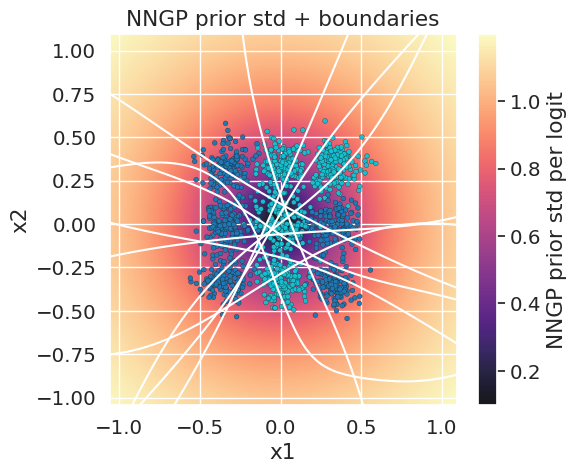

In [10]:
def nngp_prior_std_on_grid(kernel_fn, X_ref, n=300, pad=0.5, batch=1024):
    """
    Compute prior std per point: sqrt(K_nngp(x, x)) on a 2D grid without forming the full GxG kernel.
    Returns xs, ys, std_map with shape (len(ys), len(xs)).
    """
    xs, ys, Xg = make_grid_2d(X_ref, n=n, pad=pad)
    G = Xg.shape[0]
    chunks = []
    for i in range(0, G, batch):
        Xb = Xg[i:i+batch]
        # Kbb shape ~ (B, B); take diagonal then sqrt
        Kbb = kernel_fn(Xb, Xb, 'nngp')
        Kbb = jnp.asarray(Kbb)
        db = jnp.diag(Kbb)
        chunks.append(db)
    Kdiag = jnp.concatenate(chunks, axis=0)
    std_map = jnp.sqrt(Kdiag).reshape(ys.size, xs.size)
    return xs, ys, std_map

def plot_kernel_variance_with_boundaries(xs, ys, std_map, X_train, y_train, logits_list=None, C=2, title='', cmap='magma'):
    """
    Plot NNGP prior std heatmap; optionally overlay decision boundaries from prior draws.
    """
    plt.figure(figsize=(6,5))
    extent = [float(xs.min()), float(xs.max()), float(ys.min()), float(ys.max())]
    plt.imshow(jnp.asarray(std_map).T, origin='lower', extent=extent, cmap=cmap, alpha=0.9, aspect='auto')
    cb = plt.colorbar()
    cb.set_label('NNGP prior std per logit', rotation=90)
    if logits_list is not None:
        if not isinstance(logits_list, list):
            logits_list = [logits_list]
        for logits in logits_list:
            if C == 2:
                margin = (logits[:, 0] - logits[:, 1]).reshape(ys.size, xs.size)
                plt.contour(xs, ys, margin, levels=[0.0], colors='w', linewidths=1.5)
            else:
                Z = jnp.argmax(logits, axis=1).reshape(ys.size, xs.size)
                plt.contour(xs, ys, Z, levels=jnp.arange(C-1) + 0.5, colors='w', linewidths=1.0)
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=12, cmap='tab10', edgecolors='k', linewidths=0.2)
    plt.title(title or 'NNGP prior std + prior-draw boundaries')
    plt.xlabel('x1'); plt.ylabel('x2'); plt.tight_layout(); plt.show()

# Example usage: compute σ(x) on the same grid and overlay prior draw boundaries you already computed.
xs_var, ys_var, std_map = nngp_prior_std_on_grid(kernel_fn, X_train, n=600, pad=0.5, batch=1024)
plot_kernel_variance_with_boundaries(xs_var, ys_var, std_map, X_train, y_train, logits_list=logits, C=C, title='NNGP prior std + boundaries')


## Infinite Width Inference

We can use the infinite-width GP defined above to perform exact Bayesian inference using the infinite width network. To do this, we will use the function `neural_tangents.predict.gradient_descent_mse_ensemble` that performs this inference exactly. `predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, train_xs, train_ys); mean, cov = predict_fn(x_test=test_xs, get='ntk', compute_cov=True)` computes the mean and covariance of the network evaluated on the test points after training. This `predict_fn` function includes two different modes: in "NNGP" mode we compute the Bayesian posterior (which is equivalent to gradient descent with all but the last-layer weights frozen), in "NTK" mode we compute the distribution of networks after gradient descent training.

We want to do exact Bayesian inference so we'll start off using the "NNGP" setting. We will compute and plot these predictions now; we will be concerned with the standard deviation of the predictions on test points which will be given by the diagonal of the covariance matrix.

In [15]:
predict_fn = nt.predict.gradient_descent_mse_ensemble(
    kernel_fn, train_xs, train_ys_oh, diag_reg=1e-4,
)

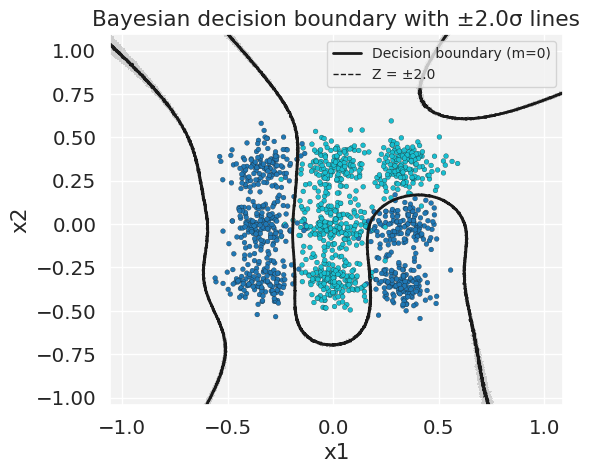

In [12]:
from matplotlib.lines import Line2D

def bayesian_decision_boundary_binary(predict_fn, X_ref, X_train, y_train, n=300, pad=0.5, batch=2048, k_std=2.0,band='fill'):
    assert C == 2, "This helper is for binary classification."
    #sample points on a grid interpolating the reference data
    #we will evaluate the NNGP posterior at these points
    xs, ys, Xg = make_grid_2d(X_ref, n=n, pad=pad)
    G = Xg.shape[0]#number of grid points

    # Posterior mean logits and per-point variance in batches
    means, vars_ = [], []
    for i in range(0, G, batch):
        Xb = Xg[i:i+batch]#get batch of grid points
        #compute posterior mean and covariance
        mb, cb = predict_fn(x_test=Xb, get='nngp', compute_cov=True)   # mean (B,2), cov (B,B)
        #the diagonal of the covariance matrix gives
        #us the variance at each point
        vb = jnp.diag(cb)                                              # (B,)
        means.append(mb)
        vars_.append(vb)

    #stack all the batches together
    mean_logits = jnp.concatenate(means, axis=0)                     # (G, 2)
    pt_var = jnp.concatenate(vars_, axis=0)                          # (G,)

    
    # Margin stats: m = f1 - f2, Var(m) = 2 * Var_per_point (outputs traced)
    # margin_mean is the difference between the gaussian process
    # outputs for class 1 and class 2 at each grid point
    # the decision boundary is where this margin is zero
    margin_mean = (mean_logits[:, 0] - mean_logits[:, 1])            # (G,)
    #get the standard deviation of the margin
    margin_std  = jnp.sqrt(jnp.clip(2.0 * pt_var, 1e-12, None))      # (G,)

    M = margin_mean.reshape(ys.size, xs.size)#get the means on the grid
    #under the gaussian process posterior,
    #the margin f1 - f2 at any fixed x is Guassian.
    #The posterior probability that class 1 is correct is P(m>0|D) = \Phi(M(x)/σ_m(x)) = \Phi(Z)
    #where \Phi is the standard normal cdf and Z is the z-score/signal to noise ratio.
    Z = (margin_mean / (margin_std + 1e-12)).reshape(ys.size, xs.size)

    plt.figure(figsize=(6,5))
    # Decision boundary (m = 0)
    plt.contour(xs, ys, M, levels=[0.0], colors='k', linewidths=2.0)
    # ±kσ lines (Z = ±k), we can think of these lines as isoprobability lines
    #where the mean margin is within k posterior standard deviations of zero.
    #e.g. k-sigma credible uncertainty interval.
    if band == 'fill':
        # Filled uncertainty bands: |Z| <= k
        band_b = (jnp.abs(Z) <= k_std).astype(float)#boolean mask where condition is met
        # filled contour requires at least two levels to fill between. Because
        # we are filling a boolean mask where the mask is 1.0, and everything else is 0.0,
        # this will shade all pts where the condition is met. any range including 1 will work
        # as long as it excludes 0.
        plt.contourf(xs, ys, band_b, levels=[0.5, 1.5], colors=[(0,0,0,0.15)])
    else:
        # Dashed isolines (less robust on rough fields)
        plt.contour(xs, ys, Z, levels=[-k_std, k_std], colors='k',
                    linestyles='--', linewidths=1.2)

    # Training points
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=12, cmap='tab10', edgecolors='k', linewidths=0.2)

    # Legend via proxy handles
    handles = [
        Line2D([], [], color='k', lw=2.0, label='Decision boundary (m=0)'),
        Line2D([], [], color='k', lw=1.0, ls='--', label=f'Z = ±{k_std}')
    ]
    plt.legend(handles=handles, fontsize=10, loc='upper right')

    plt.title(f'Bayesian decision boundary with ±{k_std}σ lines')
    plt.xlabel('x1'); plt.ylabel('x2'); plt.tight_layout(); plt.show()

# Example usage
bayesian_decision_boundary_binary(predict_fn, X_train, X_train, y_train, n=1000, pad=0.5, batch=1024, k_std=2.0, band='fill')

We see that our posterior exactly fits all of the training points as expected. We also see that the there is significant uncertainty in the predictions between the points in the middle.

Next, we would like to compute the result of doing gradient descent on our infinite network for an *infinite* amount of time. To do this, we will use the "NTK" inference mode. Note that otherwise the call to `predict_fn` looks identical. We will compare the result of true Bayesian inference with gradient descent.

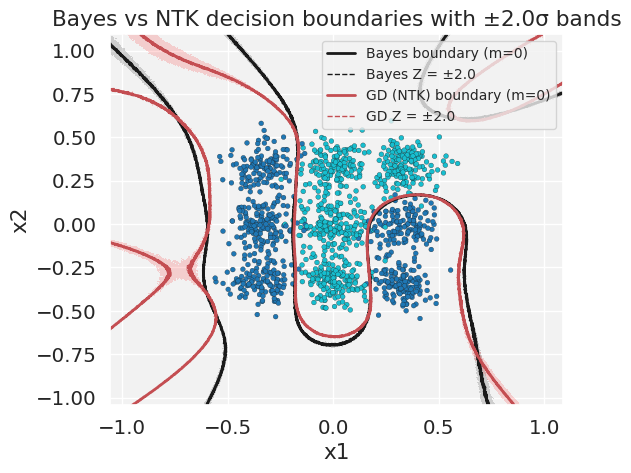

In [13]:
from scipy.ndimage import gaussian_filter
def _smooth(arr, sigma=None):
    if sigma is None or sigma <= 0: 
        return arr
    return jnp.asarray(gaussian_filter(jnp.asarray(arr), sigma=float(sigma)))

def compare_boundaries_bayes_vs_ntk_binary(
    predict_fn, X_ref, X_train, y_train, n=300, pad=0.5, batch=2048, k_std=2.0,
    colors=('k', 'r'), band='fill', sigma_smooth=None):
    assert C == 2
    def _margin_maps(get_mode):
        xs, ys, Xg = make_grid_2d(X_ref, n=n, pad=pad)
        G = Xg.shape[0]
        means, vars_ = [], []
        for i in range(0, G, batch):
            Xb = Xg[i:i+batch]
            #for both nngp and ntk the predict function returns the 
            #posterior mean and covariance of the gaussian process.
            mb, cb = predict_fn(x_test=Xb, get=get_mode, compute_cov=True)  # mean (B,2), cov (B,B) with outputs traced
            vb = jnp.diag(cb)  # per-point variance (traced over outputs)
            means.append(mb); vars_.append(vb)
        
        mean_logits = jnp.concatenate(means, axis=0)     # (G,2)
        pt_var = jnp.concatenate(vars_, axis=0)          # (G,)
        margin_mean = (mean_logits[:, 0] - mean_logits[:, 1])
        # Approx: Var(f1 - f2) ≈ 2 * Var_per_point (outputs traced)
        margin_std  = jnp.sqrt(jnp.clip(2.0 * pt_var, 1e-10, None))
        xs_s, ys_s = xs, ys
        M = margin_mean.reshape(ys.size, xs.size)
        Z = (margin_mean / margin_std).reshape(ys.size, xs.size)
        # Optional smoothing for cleaner contours
        if sigma_smooth is not None and sigma_smooth > 0:
            M = _smooth(M, sigma=sigma_smooth)
            Z = _smooth(Z, sigma=sigma_smooth)
        return xs_s, ys_s, M, Z

    xs, ys, M_bayes, Z_bayes = _margin_maps('nngp')
    _,  _, M_ntk,   Z_ntk    = _margin_maps('ntk')

    plt.figure(figsize=(6,5))
    # Decision boundaries (solid)
    plt.contour(xs, ys, M_bayes, levels=[0.0], colors=colors[0], linewidths=2.0)
    plt.contour(xs, ys, M_ntk,   levels=[0.0], colors=colors[1], linewidths=2.0)

    if band == 'fill':
        # Filled uncertainty bands: |Z| <= k
        band_b = (jnp.abs(Z_bayes) <= k_std).astype(float)
        band_n = (jnp.abs(Z_ntk)   <= k_std).astype(float)
        plt.contourf(xs, ys, band_b, levels=[0.5, 1.5], colors=[(0,0,0,0.15)])
        plt.contourf(xs, ys, band_n, levels=[0.5, 1.5], colors=[(1,0,0,0.15)])
    else:
        # Dashed isolines (less robust on rough fields)
        plt.contour(xs, ys, Z_bayes, levels=[-k_std, k_std], colors=colors[0],
                    linestyles='--', linewidths=1.2)
        plt.contour(xs, ys, Z_ntk,   levels=[-k_std, k_std], colors=colors[1],
                    linestyles='--', linewidths=1.2)

    # Training points
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=12, cmap='tab10', edgecolors='k', linewidths=0.2)

    # Legend via proxy handles
    handles = [
        Line2D([], [], color=colors[0], lw=2.0, label='Bayes boundary (m=0)'),
        Line2D([], [], color=colors[0], lw=1.0, ls='--', label=f'Bayes Z = ±{k_std}'),
        Line2D([], [], color=colors[1], lw=2.0, label='GD (NTK) boundary (m=0)'),
        Line2D([], [], color=colors[1], lw=1.0, ls='--', label=f'GD Z = ±{k_std}'),
    ]
    plt.legend(handles=handles, fontsize=10, loc='upper right')

    plt.title(f'Bayes vs NTK decision boundaries with ±{k_std}σ bands')
    plt.xlabel('x1'); plt.ylabel('x2'); plt.tight_layout(); plt.show()

# Example usage
compare_boundaries_bayes_vs_ntk_binary(predict_fn, X_train, X_train, y_train, n=1200, pad=0.5, batch=1024, k_std=2.0, sigma_smooth=0.1)

We see that while the result of gradient descent and bayesian inference are similar, they are not identical.

Not only can we do inference at infinite times, but we can also perform finite-time inference. We will use this to predict the mean of the train and test losses over the course of training. To compute the mean MSE loss, we need to access the mean and variance of our networks predictions as a function of time. To do this, we call our `predict_fn` function with finite times `t` (as opposed to using the default value `t=None` earlier, considered as infinite time). Note that `predict` can act on both scalar and array values, so we simply invoke the function.

In [19]:
def loss_curve_chunked(predict_fn, ys, ts, xs=None, batch_T=32):
    """Compute NTK MSE curve over ts without materializing all times at once."""
    ts = jnp.asarray(ts)

    # Ensure targets are (n, C)
    y_mat = ys
    if y_mat.ndim == 1:
        y_mat = one_hot(y_mat, C).astype(jnp.float32)

    out = []
    for i in range(0, int(ts.shape[0]), batch_T):
        t_chunk = ts[i:i+batch_T]
        mean, cov = predict_fn(t=t_chunk, get='ntk', x_test=xs, compute_cov=True)  # mean: (T, n, C), cov: (T, n, n)

        # Make sure mean has class dim
        if mean.ndim == 2:
            mean = mean[..., None]  # (T, n, 1)

        # Per-point variance -> broadcast across classes
        pt_var = jnp.diagonal(cov, axis1=-2, axis2=-1)    # (T, n)
        var = pt_var[..., None]                            # (T, n, 1) -> (T, n, C) by broadcasting

        y_b = y_mat[None, ...]                             # (1, n, C)
        term = y_b**2 - 2 * mean * y_b + var + mean**2     # (T, n, C)

        loss_t = 0.5 * jnp.mean(term, axis=(1, 2))         # (T,)
        #add L2 regularization term
        # loss_t += 0.5 * l2_reg * params_l2(predict_fn.params)  # scalar
        out.append(loss_t)

    return jnp.concatenate(out, axis=0)

# Use fewer, log-spaced times and chunked evaluation
ts = jnp.logspace(0, 5, 600)
ntk_train_loss_mean = loss_curve_chunked(predict_fn, train_ys, ts)
ntk_test_loss_mean  = loss_curve_chunked(predict_fn,  test_ys, ts, test_xs)

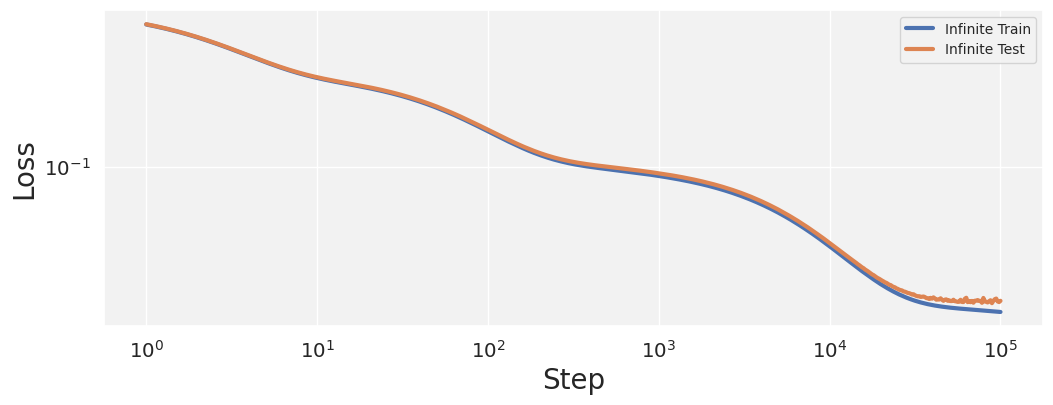

In [20]:
plt.loglog(ts, ntk_train_loss_mean, linewidth=3)
plt.loglog(ts, ntk_test_loss_mean, linewidth=3)
format_plot('Step', 'Loss')
legend(['Infinite Train', 'Infinite Test'],loc='upper right')

finalize_plot((1.5, 0.6))

## Training a Neural Network

We will now compare the results of gradient descent GP-inference computed above to the result of training an ensemble of finite width neural networks. We first train a single network drawn from the prior and then we will show how to generalize this to an ensemble. To do this we use JAX's gradient descent [optimizer](https://github.com/google/jax#first-order-optimization). Optimizers are described by a triple of functions `(init_fn, update_fn, get_params)`. Here, `init_fn(params)` takes an initial set of parameters and returns an optimizer state that can include extra information (like the velocity in the `momentum` optimizer). `opt_update(step, grads, state)` takes a new state and updates it using gradients. Finally, `get_params(state)` returns the parameters for a given state.

In [21]:
learning_rate = 0.1
training_steps = 100000

opt_init, opt_update, get_params = optimizers.sgd(learning_rate)
opt_update = jit(opt_update)

Next we need to define a loss and a gradient of the loss. We'll use an MSE loss. The function `grad` is another [JAX function](https://github.com/google/jax#automatic-differentiation-with-grad) that takes a function and returns a new function that computes its gradient.

Notably we need to add L2 regularization to the loss function to match the behavior of the infinite-width networks. This is because the infinite-width networks have an implicit L2 regularization. In our case, we set this variance to be 1e-4 above.

In [22]:
from jax.tree_util import tree_leaves
def params_l2(params):
    # sum of squared params over the pytree
    return sum([jnp.vdot(p, p) for p in tree_leaves(params)])

l2_reg = 1e-4
loss = jit(lambda params, x, y:
  0.5 * jnp.mean((apply_fn(params, x) - y) ** 2) +
  0.5 * l2_reg * params_l2(params))

grad_loss = jit(lambda state, x, y: grad(loss)(get_params(state), x, y))

Now we want to actually train the network. To do this we just initialize the optimizer state and then update it however many times we want. We'll record the train and test loss after each step.


In [23]:
train_losses = []
test_losses = []

opt_state = opt_init(params)

for i in range(training_steps):
    opt_state = opt_update(i, grad_loss(opt_state, *train), opt_state)

    train_losses += [loss(get_params(opt_state), *train)]
    test_losses += [loss(get_params(opt_state), *test)]

Finally, lets plot the loss over the course of training and the function after training compared with our GP inference.

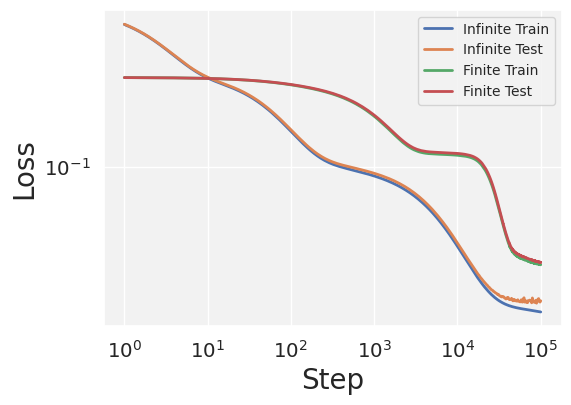

In [24]:
plt.subplot(1, 2, 1)

plt.loglog(ts, ntk_train_loss_mean, linewidth=2)
plt.loglog(ts, ntk_test_loss_mean, linewidth=2)

ts_emp = jnp.arange(1, training_steps + 1)
plt.loglog(ts_emp, train_losses, linewidth=2)
plt.loglog(ts_emp, test_losses, linewidth=2)

format_plot('Step', 'Loss')
legend(['Infinite Train', 'Infinite Test', 'Finite Train', 'Finite Test'], loc='upper right')


finalize_plot((1.5, 0.6))

## Training an Ensemble of Neural Networks

The draw above certainly seems consistent with exact inference. However, as discussed above to make a more quantitative comparison we want to train an ensemble of finite-width networks. We could use a for-loop to loop over all the different instantiations that we wanted to evaluate. However, it is more convenient and efficient to use another [JAX feature](https://github.com/google/jax#auto-vectorization-with-vmap) called `vmap`. `vmap` takes a function and vectorizes it over a batch dimension. In this case, we're going to add a batch dimension to our training loop so that we train a whole batch of neural networks at once. To do that, let's first wrap our whole training loop in a function. The function will take a random state and train a network based on that random state.

Now, to train an ensemble we just have to apply `vmap` to `train_network`. The resulting function will take a vector of random states and will train one network for each random state in the vector.

In [26]:
def loss_params(params, x, y):
    preds = apply_fn(params, x)                 # (n, C)
    mse = 0.5 * jnp.mean((preds - y) ** 2)
    return mse + 0.5 * l2_reg * params_l2(params)

grad_loss_params = jit(grad(loss_params))

def init_ensemble_params(keys):
    def _init(k): return init_fn(k, (-1, N))[1]
    return vmap(_init)(keys)                    # PyTree with leading dim = E

def init_ensemble_optimizer(params_E):
    return vmap(opt_init)(params_E)             # batched optimizer state PyTree

@partial(jit, static_argnames=('steps', 'log_every', 'compute_test'))
def train_ensemble_scanned_with_logs(opt_state_E, steps: int, log_every: int = 100, compute_test: bool = True):
    def step_once(carry, _):
        s, i = carry
        params_E = vmap(get_params)(s)  # (E, ...)
        grads_E = vmap(grad_loss_params, in_axes=(0, None, None))(params_E, train_xs, train_ys_oh)  # (E, ...)
        s = vmap(opt_update, in_axes=(None, 0, 0))(i, grads_E, s)
        return (s, i + 1), None

    def do_k_steps(s, i, k: int):
        (s2, i2), _ = jax.lax.scan(step_once, (s, i), xs=None, length=k)
        return s2, i2

    def block_body(carry, _):
        s, i = carry
        s, i = do_k_steps(s, i, log_every)
        params_E = vmap(get_params)(s)
        train_loss = vmap(loss_params, in_axes=(0, None, None))(params_E, train_xs, train_ys_oh)  # (E,)
        if compute_test:
            test_loss = vmap(loss_params, in_axes=(0, None, None))(params_E, test_xs, test_ys_oh)   # (E,)
        else:
            test_loss = jnp.zeros_like(train_loss)
        return (s, i), (train_loss, test_loss)

    n_full = steps // log_every
    rem = steps - n_full * log_every

    (s_full, i_full), (train_logs_full, test_logs_full) = jax.lax.scan(
        block_body,
        (opt_state_E, jnp.array(0, dtype=jnp.int32)),
        xs=None,
        length=n_full,
    )  # train_logs_full: (n_full, E)

    # Handle remainder
    def do_rem(s, i):
        s, i = do_k_steps(s, i, rem)
        params_E = vmap(get_params)(s)
        train_loss = vmap(loss_params, in_axes=(0, None, None))(params_E, train_xs, train_ys_oh)
        if compute_test:
            test_loss = vmap(loss_params, in_axes=(0, None, None))(params_E, test_xs, test_ys_oh)
        else:
            test_loss = jnp.zeros_like(train_loss)
        return s, i, train_loss[None, :], test_loss[None, :]

    if rem > 0:
        s_final, i_final, train_last, test_last = do_rem(s_full, i_full)
        train_logs = jnp.concatenate([train_logs_full, train_last], axis=0)  # (n_logs, E)
        test_logs  = jnp.concatenate([test_logs_full,  test_last],  axis=0)  # (n_logs, E)
    else:
        s_final, i_final = s_full, i_full
        train_logs, test_logs = train_logs_full, test_logs_full

    # Steps at which logs were taken
    steps_logged = jnp.concatenate([
        jnp.arange(log_every, n_full * log_every + 1, log_every, dtype=jnp.int32),
        jnp.array([steps], dtype=jnp.int32) if rem > 0 else jnp.array([], dtype=jnp.int32)
    ], axis=0)  # (n_logs,)

    return s_final, train_logs, test_logs, steps_logged

# Usage
ensemble_size = 100
ensemble_key = random.split(key, ensemble_size)
params0_E = vmap(lambda k: init_fn(k, (-1, N))[1])(ensemble_key)
opt_state_E = vmap(opt_init)(params0_E)

# Warmup compile
_ = train_ensemble_scanned_with_logs(opt_state_E, steps=1, log_every=1, compute_test=False)

# Train and log every K steps
log_every = 500
opt_state_E, train_logs, test_logs, steps_logged = train_ensemble_scanned_with_logs(
    opt_state_E, steps=training_steps, log_every=log_every, compute_test=True
)

# Final params and per-ensemble curves
params_E = vmap(get_params)(opt_state_E)               # PyTree with leading dim E
train_loss_E_curve = jnp.swapaxes(train_logs, 0, 1)    # (E, n_logs)
test_loss_E_curve  = jnp.swapaxes(test_logs,  0, 1)    # (E, n_logs)

# Optional: final losses per ensemble
final_train_loss_E = vmap(loss_params, in_axes=(0, None, None))(params_E, train_xs, train_ys_oh)  # (E,)
final_test_loss_E  = vmap(loss_params, in_axes=(0, None, None))(params_E,  test_xs,  test_ys_oh)  # (E,)


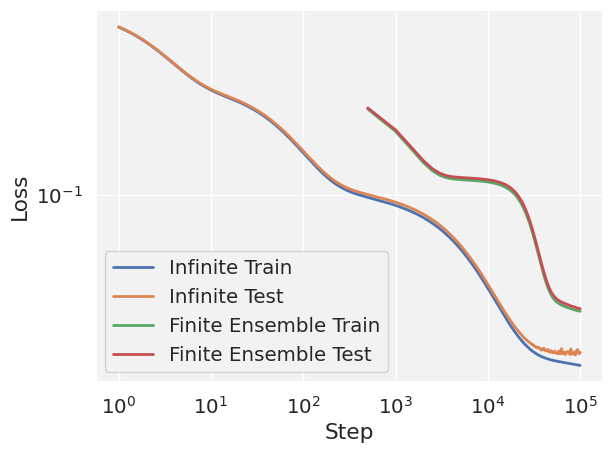

In [27]:
# Plot ensemble mean vs NTK curves at logged steps
mean_train = jnp.mean(train_logs, axis=1)  # (n_logs,)
mean_test  = jnp.mean(test_logs,  axis=1)  # (n_logs,)
plt.loglog(ts, ntk_train_loss_mean, linewidth=2, label='Infinite Train')
plt.loglog(ts, ntk_test_loss_mean,  linewidth=2, label='Infinite Test')
plt.loglog(steps_logged, mean_train, linewidth=2, label='Finite Ensemble Train')
plt.loglog(steps_logged, mean_test,  linewidth=2, label='Finite Ensemble Test')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

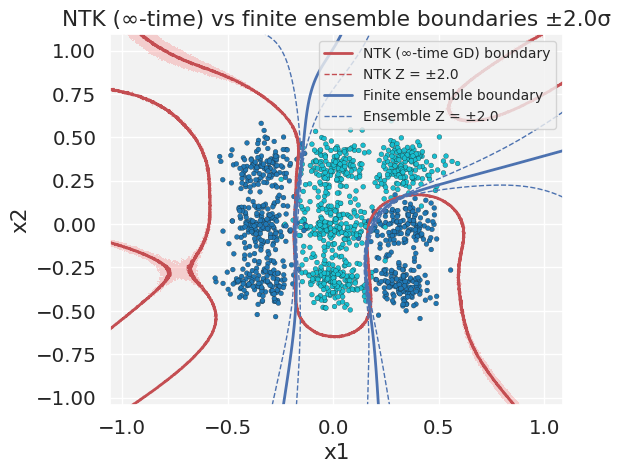

In [29]:
from jax.tree_util import tree_map, tree_leaves

def ensure_stacked_params(p):
    # If given a list/tuple of param trees with identical structure, stack them.
    if isinstance(p, (list, tuple)) and len(p) > 0:
        try:
            t0 = jax.tree.structure(p[0])
            if all(jax.tree.structure(e) == t0 for e in p):
                return jax.tree_map(lambda *xs: jnp.stack(xs, axis=0), *p)
        except Exception:
            pass  # fall through to treat `p` as a single param tree

    # If already stacked on leading axis (E, ...), leave as-is.
    leaves = tree_leaves(p)
    if leaves and all((l.ndim > 0) and (l.shape[0] == leaves[0].shape[0]) for l in leaves):
        return p

    # Otherwise, wrap a singleton leading axis.
    return tree_map(lambda x: x[None, ...], p)

def compare_ntk_vs_ensemble_binary(
    predict_fn, ens_params, X_ref, X_train, y_train,
    n=300, pad=0.5, batch=2048, k_std=2.0,
    colors=('r', 'b'), show_bands_ntk=True, show_bands_ens=True,
    band='fill'
):
    assert C == 2, "This helper is for binary classification."
    xs, ys, Xg = make_grid_2d(X_ref, n=n, pad=pad)
    G = Xg.shape[0]

    # NTK part (unchanged)
    ntk_margin_means, ntk_margin_stds = [], []
    for i in range(0, G, batch):
        Xb = Xg[i:i+batch]
        if show_bands_ntk:
            mb, cb = predict_fn(x_test=Xb, get='ntk', compute_cov=True)
            vb = jnp.diag(cb)
            ntk_margin_stds.append(jnp.sqrt(jnp.clip(2.0 * vb, 1e-12, None)))
        else:
            mb, _ = predict_fn(x_test=Xb, get='ntk', compute_cov=False)
        ntk_margin_means.append(mb[:, 0] - mb[:, 1])
    ntk_margin_mean = jnp.concatenate(ntk_margin_means, axis=0)
    M_ntk = ntk_margin_mean.reshape(ys.size, xs.size)
    if show_bands_ntk:
        ntk_margin_std = jnp.concatenate(ntk_margin_stds, axis=0)
        Z_ntk = (ntk_margin_mean / (ntk_margin_std + 1e-12)).reshape(ys.size, xs.size)

    # Ensure params are stacked on axis 0
    ens_params = ensure_stacked_params(ens_params)

    # Ensemble part
    ens_margin_means, ens_margin_stds = [], []
    for i in range(0, G, batch):
        Xb = Xg[i:i+batch]
        logits_ens = vmap(apply_fn, in_axes=(0, None))(ens_params, Xb)  # (E, B, C)
        m = logits_ens[:, :, 0] - logits_ens[:, :, 1]                  # (E, B)
        ens_margin_means.append(jnp.mean(m, axis=0))                   # (B,)
        if show_bands_ens:
            ens_margin_stds.append(jnp.std(m, axis=0))                   # (B,)

    ens_margin_mean = jnp.concatenate(ens_margin_means, axis=0)
    M_ens = ens_margin_mean.reshape(ys.size, xs.size)
    if show_bands_ens:
        ens_margin_std = jnp.concatenate(ens_margin_stds, axis=0)
        Z_ens = (ens_margin_mean / (ens_margin_std + 1e-12)).reshape(ys.size, xs.size)

    plt.figure(figsize=(6,5))
    plt.contour(xs, ys, M_ntk, levels=[0.0], colors=colors[0], linewidths=2.0)
    if show_bands_ntk:
        if band == 'fill':
            band_n = (jnp.abs(Z_ntk) <= k_std).astype(float)
            plt.contourf(xs, ys, band_n, levels=[0.5, 1.5], colors=[(1,0,0,0.15)])
        else:
            plt.contour(xs, ys, Z_ntk, levels=[-k_std, k_std], colors=colors[0], linestyles='--', linewidths=1.0)
    
    plt.contour(xs, ys, M_ens, levels=[0.0], colors=colors[1], linewidths=2.0)
    if show_bands_ens:
        plt.contour(xs, ys, Z_ens, levels=[-k_std, k_std], colors=colors[1], linestyles='--', linewidths=1.0)
    plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=12, cmap='tab10', edgecolors='k', linewidths=0.2)
    handles = [
        Line2D([], [], color=colors[0], lw=2.0, label='NTK (∞-time GD) boundary'),
        Line2D([], [], color=colors[0], lw=1.0, ls='--', label=f'NTK Z = ±{k_std}') if show_bands_ntk else None,
        Line2D([], [], color=colors[1], lw=2.0, label='Finite ensemble boundary'),
        Line2D([], [], color=colors[1], lw=1.0, ls='--', label=f'Ensemble Z = ±{k_std}') if show_bands_ens else None,
    ]
    handles = [h for h in handles if h is not None]
    plt.legend(handles=handles, fontsize=10, loc='upper right')
    plt.title(f'NTK (∞-time) vs finite ensemble boundaries ±{k_std}σ')
    plt.xlabel('x1'); plt.ylabel('x2'); plt.tight_layout(); plt.show()

# Example usage: pass params_E (stacked) from vmap(get_params)(opt_state_E)
compare_ntk_vs_ensemble_binary(
  predict_fn, params_E, X_train, X_train, y_train,
  n=1200, pad=0.5, batch=1024, k_std=2.0, colors=('r','b'),
  show_bands_ntk=True, show_bands_ens=True
)

Now let's try this out for bias only networks. We can modify the call to `Dense` to indicate that we only want to train the bias terms.

In [30]:
b_init_fn, b_apply_fn, b_kernel_fn = stax.serial(
    stax.Dense(32, W_std=1.5, b_std=0.05, trainable=("b",)), stax.Erf(),
    # stax.Dense(32, W_std=1.5, b_std=0.05, trainable=("b",)), stax.Erf(),
    stax.Dense(C, W_std=1.5, b_std=0.05, trainable=("b",))
)

b_apply_fn = jit(b_apply_fn)
b_kernel_fn = jit(b_kernel_fn, static_argnames='get')

Let's now again visualize the function space prior when only training the bias terms. This should be the same as before since the prior is unaffected by which parameters are trained.

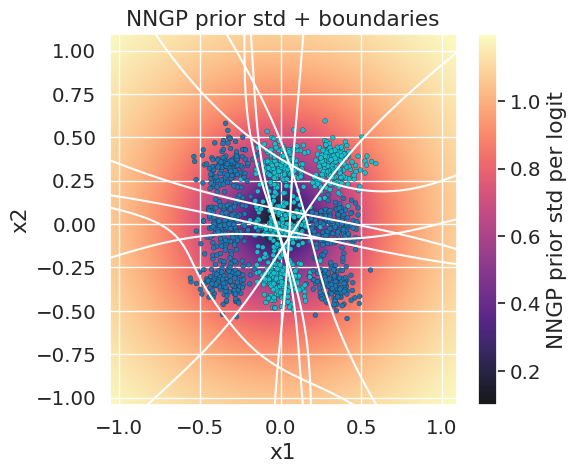

In [34]:
#each p in prior_draws is (num_test_points, C)
#to get the predicted labels take the argmax across axis 1
xs, ys, logits, Zs = [], [], [], []
prior_draws = []
for _ in range(10):
    key, net_key = random.split(key)
    _, params = b_init_fn(net_key, (-1, N))
    out = getLogits_NTK(lambda x: b_apply_fn(params, x), test_xs, n=600, pad=0.5)
    xs += [out[0]]
    ys += [out[1]]
    logits += [out[2]]
    Zs += [out[3]]

xs_var, ys_var, std_map = nngp_prior_std_on_grid(b_kernel_fn, X_train, n=600, pad=0.5, batch=1024)
plot_kernel_variance_with_boundaries(xs_var, ys_var, std_map, X_train, y_train, logits_list=logits, C=C, title='NNGP prior std + boundaries')

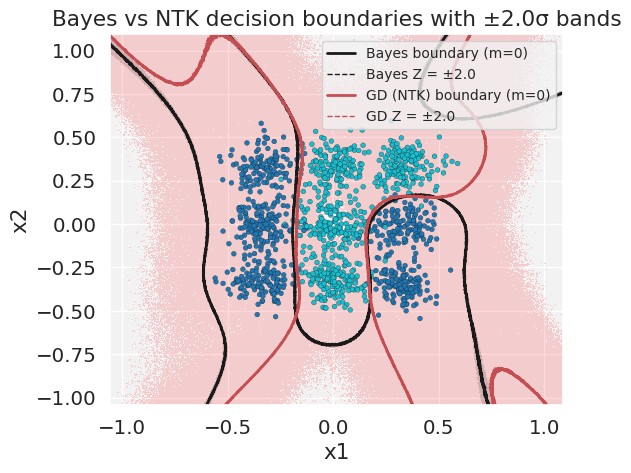

In [39]:
b_predict_fn = nt.predict.gradient_descent_mse_ensemble(
    b_kernel_fn, train_xs, train_ys_oh, diag_reg=1e-4,
)

compare_boundaries_bayes_vs_ntk_binary(b_predict_fn, X_train, X_train, y_train, n=1200, pad=0.5, batch=1024, k_std=2.0)

As before let's perform finite-time inference. We will use this to predict the mean of the train and test losses over the course of training.

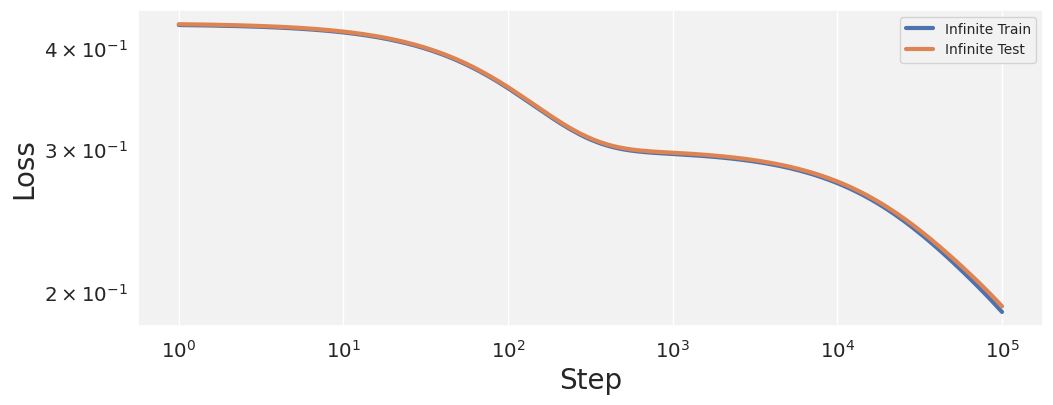

In [40]:
# Use fewer, log-spaced times and chunked evaluation
ts = jnp.logspace(0, 5, 600)
ntk_train_loss_mean = loss_curve_chunked(b_predict_fn, train_ys, ts)
ntk_test_loss_mean  = loss_curve_chunked(b_predict_fn,  test_ys, ts, test_xs)

plt.loglog(ts, ntk_train_loss_mean, linewidth=3)
plt.loglog(ts, ntk_test_loss_mean, linewidth=3)
format_plot('Step', 'Loss')
legend(['Infinite Train', 'Infinite Test'],loc='upper right')

finalize_plot((1.5, 0.6))

Next, let's compare the function learned by the ensemble of bias-only networks with the prediction of the NTK theory.

In [44]:
def loss_params_bias(params, x, y, l2_reg=0.0):
    preds = b_apply_fn(params, x)               # (n, C)
    mse = 0.5 * jnp.mean((preds - y) ** 2)
    return mse + 0.5 * l2_reg * params_l2(params)   # only biases have nonzero grads

grad_loss_params_bias = jit(grad(loss_params_bias))

def make_bias_mask(tree):
    if isinstance(tree, dict):
        return {k: (jnp.ones_like(v) if k == 'b'
                    else jnp.zeros_like(v) if k == 'w'
                    else make_bias_mask(v))
                for k, v in tree.items()}
    elif isinstance(tree, (list, tuple)):
        return type(tree)(make_bias_mask(v) for v in tree)
    else:
        return jnp.ones_like(tree)

@partial(jit, static_argnames=('steps','log_every','compute_test'))
def train_ensemble_scanned_with_logs_bias(opt_state_E, mask_E, steps: int, log_every: int = 100, compute_test: bool = True, l2_reg: float = 0.0):
    def step_once(carry, _):
        s, i = carry
        params_E = vmap(get_params)(s)
        grads_E = vmap(grad_loss_params_bias, in_axes=(0, None, None, None))(params_E, train_xs, train_ys_oh, l2_reg)
        grads_E = jax.tree_util.tree_map(lambda g, m: g * m, grads_E, mask_E)  # freeze weights
        s = vmap(opt_update, in_axes=(None, 0, 0))(i, grads_E, s)
        return (s, i + 1), None

    def do_k_steps(s, i, k: int):
        (s2, i2), _ = jax.lax.scan(step_once, (s, i), xs=None, length=k)
        return s2, i2

    def block_body(carry, _):
        s, i = carry
        s, i = do_k_steps(s, i, log_every)
        params_E = vmap(get_params)(s)
        train_loss = vmap(loss_params_bias, in_axes=(0, None, None, None))(params_E, train_xs, train_ys_oh, l2_reg)
        test_loss  = vmap(loss_params_bias, in_axes=(0, None, None, None))(params_E, test_xs, test_ys_oh, l2_reg) if compute_test else jnp.zeros_like(train_loss)
        return (s, i), (train_loss, test_loss)

    n_full = steps // log_every
    rem = steps - n_full * log_every
    (s_full, i_full), (train_logs_full, test_logs_full) = jax.lax.scan(block_body, (opt_state_E, jnp.array(0, jnp.int32)), xs=None, length=n_full)

    def do_rem(s, i):
        s, i = do_k_steps(s, i, rem)
        params_E = vmap(get_params)(s)
        train_loss = vmap(loss_params_bias, in_axes=(0, None, None, None))(params_E, train_xs, train_ys_oh, l2_reg)
        test_loss  = vmap(loss_params_bias, in_axes=(0, None, None, None))(params_E, test_xs, test_ys_oh, l2_reg) if compute_test else jnp.zeros_like(train_loss)
        return s, i, train_loss[None, :], test_loss[None, :]

    if rem > 0:
        s_final, i_final, train_last, test_last = do_rem(s_full, i_full)
        train_logs = jnp.concatenate([train_logs_full, train_last], axis=0)
        test_logs  = jnp.concatenate([test_logs_full,  test_last],  axis=0)
    else:
        s_final, i_final = s_full, i_full
        train_logs, test_logs = train_logs_full, test_logs_full

    steps_logged = jnp.concatenate([
        jnp.arange(log_every, n_full * log_every + 1, log_every, dtype=jnp.int32),
        jnp.array([steps], dtype=jnp.int32) if rem > 0 else jnp.array([], dtype=jnp.int32)
    ], axis=0)

    return s_final, train_logs, test_logs, steps_logged

# Init ensemble with bias-only params and mask
ensemble_size = 100
ensemble_key = random.split(key, ensemble_size)
params0_E = vmap(lambda k: b_init_fn(k, (-1, N))[1])(ensemble_key)
mask_E = vmap(make_bias_mask)(params0_E)
opt_state_E = vmap(opt_init)(params0_E)

# Compile and train
l2_reg = 0.0
_ = train_ensemble_scanned_with_logs_bias(opt_state_E, mask_E, steps=1, log_every=1, compute_test=False, l2_reg=l2_reg)
log_every = 100
opt_state_E, train_logs, test_logs, steps_logged = train_ensemble_scanned_with_logs_bias(
    opt_state_E, mask_E, steps=training_steps, log_every=log_every, compute_test=True, l2_reg=l2_reg
)

params_E = vmap(get_params)(opt_state_E)
# Final params and per-ensemble curves
train_loss_E_curve = jnp.swapaxes(train_logs, 0, 1)    # (E, n_logs)
test_loss_E_curve  = jnp.swapaxes(test_logs,  0, 1)    # (E, n_logs)

# Optional: final losses per ensemble
final_train_loss_E = vmap(loss_params_bias, in_axes=(0, None, None))(params_E, train_xs, train_ys_oh)  # (E,)
final_test_loss_E  = vmap(loss_params_bias, in_axes=(0, None, None))(params_E,  test_xs,  test_ys_oh)  # (E,)


Visualize losses

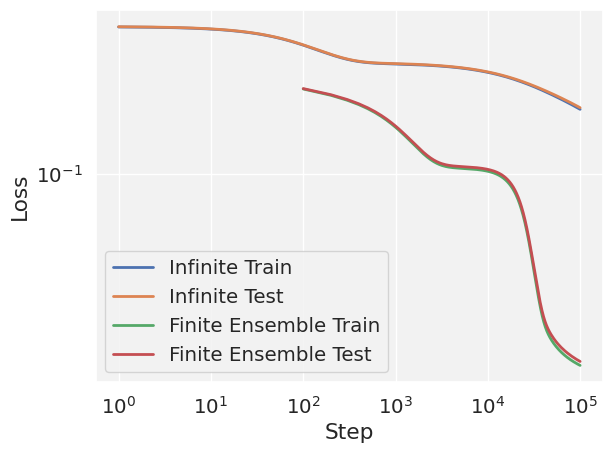

In [45]:
# Plot ensemble mean vs NTK curves at logged steps
mean_train = jnp.mean(train_logs, axis=1)  # (n_logs,)
mean_test  = jnp.mean(test_logs,  axis=1)  # (n_logs,)
plt.loglog(ts, ntk_train_loss_mean, linewidth=2, label='Infinite Train')
plt.loglog(ts, ntk_test_loss_mean,  linewidth=2, label='Infinite Test')
plt.loglog(steps_logged, mean_train, linewidth=2, label='Finite Ensemble Train')
plt.loglog(steps_logged, mean_test,  linewidth=2, label='Finite Ensemble Test')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Compare decision boundaries between NTK prediction and the ensemble of bias-only networks.

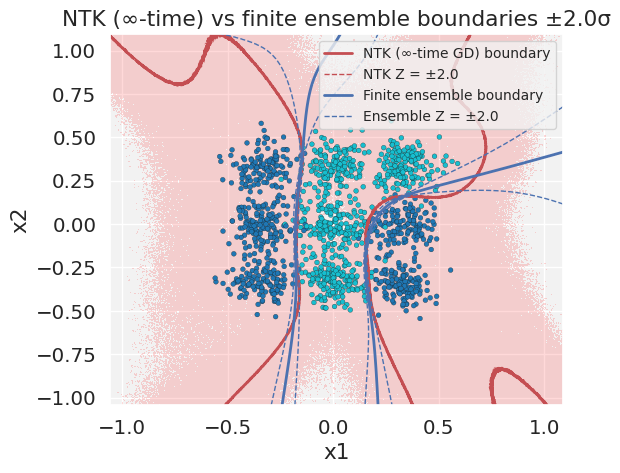

In [43]:
# Example usage: pass params_E (stacked) from vmap(get_params)(opt_state_E)
compare_ntk_vs_ensemble_binary(
  b_predict_fn, params_E, X_train, X_train, y_train,
  n=1200, pad=0.5, batch=1024, k_std=2.0, colors=('r','b'),
  show_bands_ntk=True, show_bands_ens=True
)